In [24]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 29
day = 23

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

29 23
optimal travel lag is 6.856856856856858 cm based on kde of travel at max spatial information
optimal travel lag is 6.856856856856858 cm
there are 158 non_grid and non_spatial_cells
there are 24 grid_cells
there are 149 non grid spatial cells
there are 9 non spatial cells
there are 29 speed cells
there are 211 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'PAR']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR']
there are 207 MEC cells
there are 4 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 211 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Merging labels 0 and 1 with distance 6.480460847707891
Found 2 modules with HDBSCAN for mouse 29 day 23
for each module , t

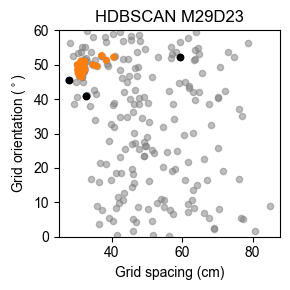

for module 0, there are 21 cells with average spacing 32.709071671458304
module 0 contains cells from ['ENTm2' 'ENTm3' 'ENTm5' 'PAR']
29 23
for module 0, there are 21 cells
plotting vr rate maps using cluster_ids [26, 110, 132, 133, 144, 156, 160, 178, 181, 184, 191, 202, 204, 210, 213, 214, 216, 217, 219, 389, 411]


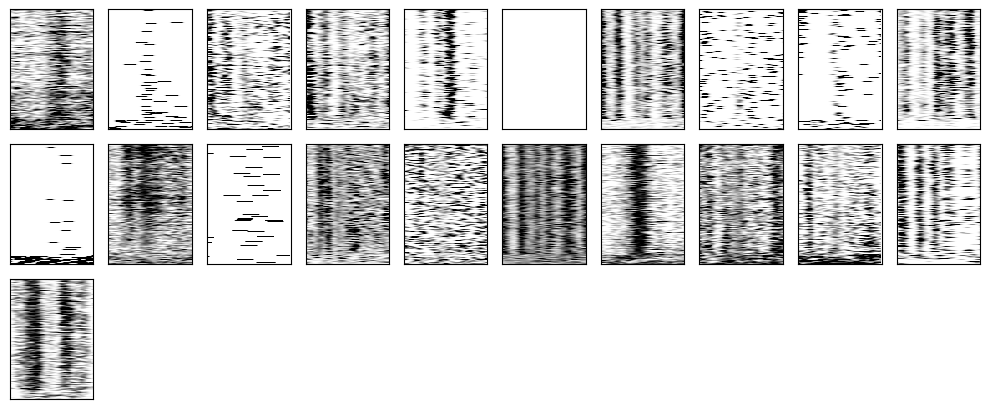

plotting vr rate maps using cluster_ids [24, 28, 42, 53, 61, 65, 79, 81, 84, 86, 87, 89, 95, 101, 103, 104, 108, 157, 163, 169, 171, 186, 196, 198, 203, 205, 211, 215, 221, 224, 226, 231, 238, 239, 241, 247, 249, 251, 255, 256, 257, 259, 262, 266, 267, 269, 270, 278, 284, 287, 288, 291, 292, 293, 296, 297, 301, 303, 311, 312, 314, 315, 318, 319, 321, 323, 326, 327, 329, 331, 332, 334, 338, 340, 341, 342, 343, 345, 346, 349, 350, 352, 353, 354, 355, 356, 358, 362, 363, 366, 368, 369, 370, 371, 373, 374, 375, 376, 377, 378, 380, 381, 382, 383, 385, 387, 388, 391, 392, 393, 394, 396, 397, 398, 399, 400, 403, 404, 405, 409, 412, 414, 416, 418, 419, 420, 421, 422, 425, 426, 427, 429, 430, 431, 433, 434, 440, 445, 446, 450, 451, 452, 461, 462, 464, 466, 467, 469, 472]


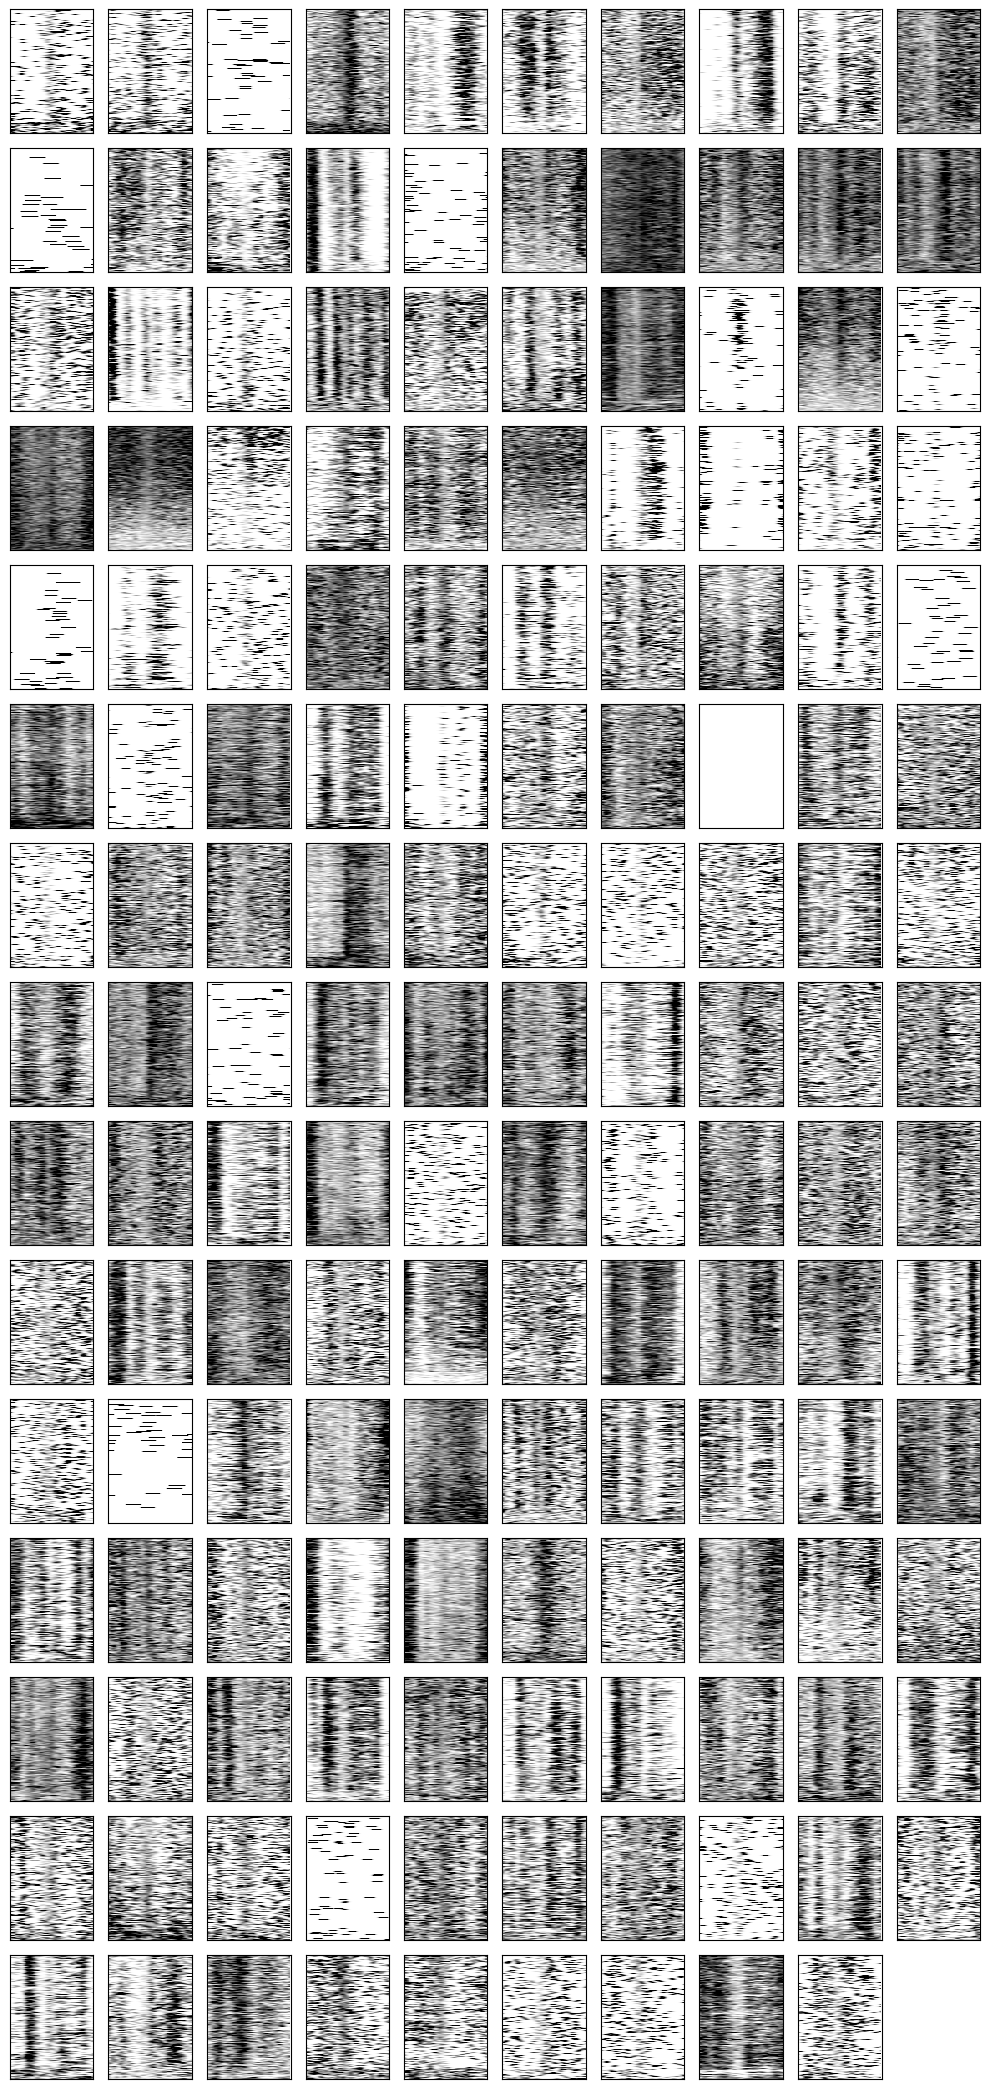

plotting vr rate maps using cluster_ids [46, 218, 220, 271, 313, 364, 365, 379, 386]


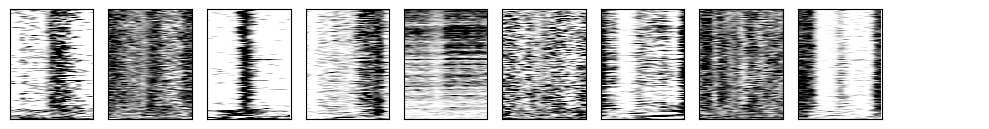

plotting vr rate maps using cluster_ids [26, 110, 132, 133, 144, 156, 160, 178, 179, 181, 184, 191, 194, 202, 204, 210, 213, 214, 216, 217, 219, 302, 389, 411]


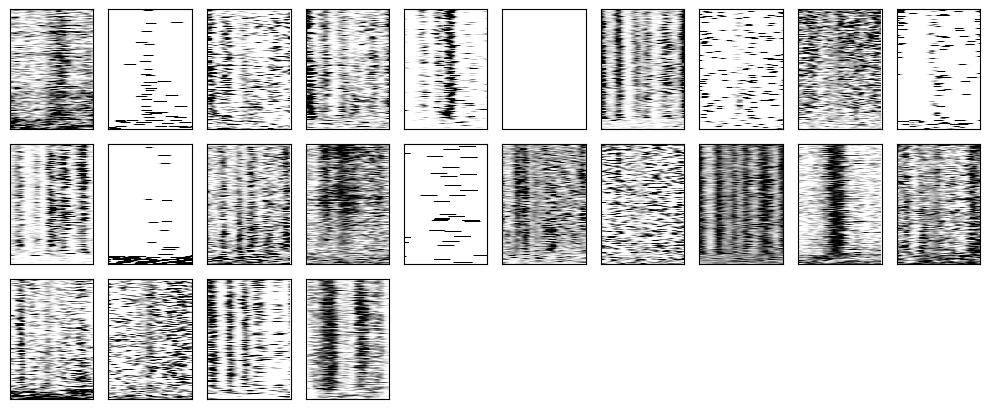

plotting vr rate maps using cluster_ids [20, 29, 30, 32, 33, 34, 244, 268, 272, 275, 286, 290, 316, 317, 328, 335, 336, 337, 359, 367, 408, 428, 444, 447, 454, 457, 458, 459, 463]


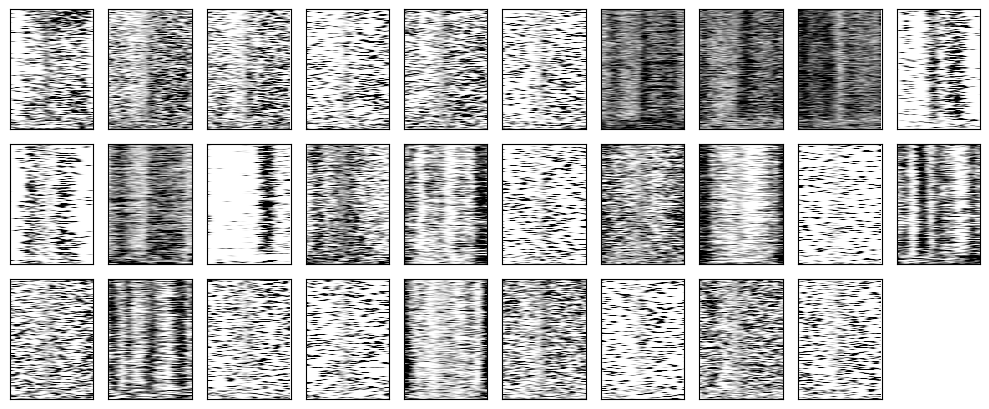

plotting vr rate maps using cluster_ids [179 194 302]


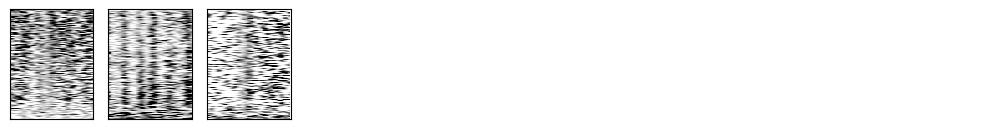

In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)
g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

plot_vr_rate_maps(mouse, day, np.setdiff1d(gcs.cluster_id.values, g_m_cluster_ids[0]), label=f'nocomodular_grid_cells', figpath=fig_path)

In [4]:
Mouse = f'M{mouse}'
data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
clusters_df = clusters_df[clusters_df['mouse'] == mouse]
shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
clusters_df = reconstruct_shank_id(clusters_df, mouse)
probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)

ymin = -300; ymax = 3000
xmin = -200; xmax = 1000
xs = np.arange(xmin, xmax, 1)
ys = np.arange(ymin, ymax, 1)

annotations = np.zeros((len(ys), len(xs)), dtype=object)
for yi, y in enumerate(ys):
    for xi, x in enumerate(xs):
        coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
        # use the CCF coordinates, get an index and look up the annotation in the brainrender allen_brain_10um volume
        z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
        annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
        if len(structure_set[structure_set['id'] == annotation_index]) ==1:
            annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
        else:
            annotation ='root' # out of brain
        annotations[yi,xi] = annotation

In [5]:
annotation_colors = get_annotation_colors_2D(annotations)

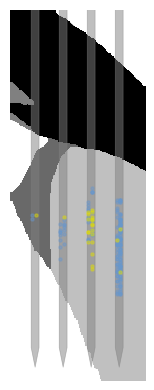

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
unique_colors = np.unique(annotation_colors)
for color in unique_colors:
    border_points = extract_border(annotation_colors, color, only_border=False)
    x_points = xs[border_points[:, 1]]
    y_points = ys[border_points[:, 0]]
    ax.scatter(x_points, y_points, color=color, s=1, label=color, rasterized=True)
plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
               probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
# plot cell locations 
ax.scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="#6897CD", alpha=0.4, s=5)
ax.scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color="#E3E000", alpha=0.4, s=5)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_probe_brainrender.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()

In [7]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)

last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

In [8]:
figpath_rm = '/Users/harryclark/Desktop/temp/'

for id in gcs.cluster_id.values:
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    unique_colors = np.unique(annotation_colors)
    for color in unique_colors:
        border_points = extract_border(annotation_colors, color, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax.scatter(x_points, y_points, color=color, s=1, label=color, rasterized=True)
    plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
    # plot cell locations 
    ax.scatter(gcs[gcs.cluster_id==id].probe_x.values, gcs[gcs.cluster_id==id].probe_y.values, marker='o', color="#E3E000", alpha=0.4, s=5)
    plt.tight_layout()
    plt.savefig(f'{figpath_rm}M{mouse}D{day}GC{id}_probe_brainrender.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
    plt.close()

for id in ngs.cluster_id.values:
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    unique_colors = np.unique(annotation_colors)
    for color in unique_colors:
        border_points = extract_border(annotation_colors, color, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax.scatter(x_points, y_points, color=color, s=1, label=color, rasterized=True)
    plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
    # plot cell locations 
    ax.scatter(ngs[ngs.cluster_id==id].probe_x.values, ngs[ngs.cluster_id==id].probe_y.values, marker='o', color="#E3E000", alpha=0.4, s=5)
    plt.tight_layout()
    plt.savefig(f'{figpath_rm}M{mouse}D{day}NGS{id}_probe_brainrender.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
    plt.close()
plot_individual_rate_maps_with_avg_by_trial_type(mouse, day, cluster_ids=gcs.cluster_id.values, label='GC', figpath=figpath_rm)
plot_individual_rate_maps_with_avg_by_trial_type(mouse, day, cluster_ids=ngs.cluster_id.values, label='NGS', figpath=figpath_rm)


In [9]:
plot_individual_of_rate_maps_optimal_versus_standard(mouse, day, df=gcs, label='GC', figpath=figpath_rm) 
plot_individual_of_rate_maps_optimal_versus_standard(mouse, day, df=ngs, label='NGS', figpath=figpath_rm)

29 23
29 23


In [10]:
test_grid_cell_id = 214  # the grid cell we will use to test the model
predictor_grid_cell_id_1 = 194
predictor_grid_cell_id_2 = 389
predictor_non_grid_cell_id_3 = 65
predictor_non_grid_cell_id_4 = 198
predictor_non_grid_cell_id_5 = 241
predictor_non_grid_cell_id_6 = 404

In [11]:
gcs_minus_test = gcs[gcs.cluster_id != test_grid_cell_id]
cov_tcs_time_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in gcs_minus_test.cluster_id.values if cluster_id in tcs_time}
cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs_time}

In [12]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

y = np.array(tcs_time[test_grid_cell_id]) # target variable is the test grid cell
y_smoothed = gaussian_filter_nan(y, sigma=3) # smooth the target variable
X  = np.stack([pos_in_time]).T # pos in time

Xg1 = np.stack([np.array(tcs_time[predictor_grid_cell_id_1])]).T # grid cell 10
Xg2 = np.stack([np.array(tcs_time[predictor_grid_cell_id_2])]).T # grid cell 11
Xngs3 = np.stack([np.array(tcs_time[predictor_non_grid_cell_id_3])]).T # ngs cell 2
Xngs4 = np.stack([np.array(tcs_time[predictor_non_grid_cell_id_4])]).T # ngs cell 3
Xngs5 = np.stack([np.array(tcs_time[predictor_non_grid_cell_id_5])]).T # ngs cell 4
Xngs6 = np.stack([np.array(tcs_time[predictor_non_grid_cell_id_6])]).T # ngs cell 5 
Xgmax = np.column_stack((np.vstack(list(cov_tcs_time_grids.values())).T)).T # grid cells         
Xngsmax = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T # non grid spatial cells        

Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[predictor_grid_cell_id_1])]).T # grid cell 10 + pos in time
Xpos_g2 = np.stack([pos_in_time, np.array(tcs_time[predictor_grid_cell_id_2])]).T # grid cell 11 + pos in time
Xpos_ngs3 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_grid_cell_id_3])]).T # ngs cell 2 + pos in time
Xpos_ngs4 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_grid_cell_id_4])]).T # ngs cell 3 + pos in time
Xpos_ngs5 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_grid_cell_id_5])]).T # ngs cell 4 + pos in time
Xpos_ngs6 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_grid_cell_id_6])]).T # ngs cell 5

Xpos_gmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_grids.values())).T)) # grid cells + pos in time     
Xpos_ngsmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T)) # non grid spatial cells + pos in time


Y_hat_p, pR2_cv_p = xgb_history.fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1, pR2_cv_g1 = xgb_history.fit_cv(Xg1, y, verbose = 0, continuous_folds = True)
Y_hat_g2, pR2_cv_g2 = xgb_history.fit_cv(Xg2, y, verbose = 0, continuous_folds = True)
Y_hat_ngs3, pR2_cv_ngs3 = xgb_history.fit_cv(Xngs3, y, verbose = 0, continuous_folds = True)
Y_hat_ngs4, pR2_cv_ngs4 = xgb_history.fit_cv(Xngs4, y, verbose = 0, continuous_folds = True)
Y_hat_ngs5, pR2_cv_ngs5 = xgb_history.fit_cv(Xngs5, y, verbose = 0, continuous_folds = True)
Y_hat_ngs6, pR2_cv_ngs6 = xgb_history.fit_cv(Xngs6, y, verbose = 0, continuous_folds = True)
Y_hat_gmax, pR2_cv_gmax = xgb_history.fit_cv(Xgmax, y, verbose = 0, continuous_folds = True)
Y_hat_ngsmax, pR2_cv_ngsmax = xgb_history.fit_cv(Xngsmax, y, verbose = 0, continuous_folds = True)
Y_hat_pos_g1, pR2_cv_pos_g1 = xgb_history.fit_cv(Xpos_g1, y, verbose = 0, continuous_folds = True)
Y_hat_pos_g2, pR2_cv_pos_g2 = xgb_history.fit_cv(Xpos_g2, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs3, pR2_cv_pos_ngs3 = xgb_history.fit_cv(Xpos_ngs3, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs4, pR2_cv_pos_ngs4 = xgb_history.fit_cv(Xpos_ngs4, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs5, pR2_cv_pos_ngs5 = xgb_history.fit_cv(Xpos_ngs5, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs6, pR2_cv_pos_ngs6 = xgb_history.fit_cv(Xpos_ngs6, y, verbose = 0, continuous_folds = True)
Y_hat_pos_gmax, pR2_cv_pos_gmax = xgb_history.fit_cv(Xpos_gmax, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngsmax, pR2_cv_pos_ngsmax = xgb_history.fit_cv(Xpos_ngsmax, y, verbose = 0, continuous_folds = True)


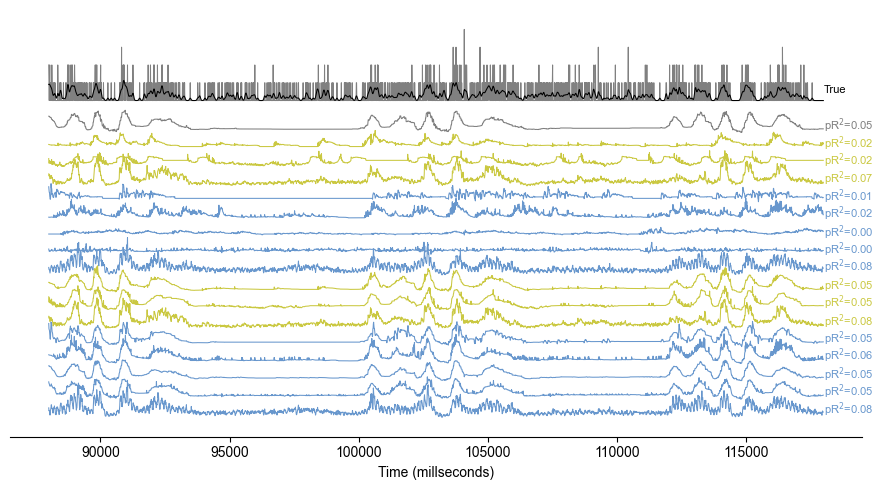

In [13]:
offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(9, 5))
start=9000-200
end=12000-200
sf = -4 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-1), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-1), label='True', color='black', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p))[start:end]*time_bs, Y_hat_p[start:end]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1))[start:end]*time_bs, Y_hat_g1[start:end]*sf + (offset*2), color='#CAC841', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_g2))[start:end]*time_bs, Y_hat_g2[start:end]*sf + (offset*3), color='#CAC841', linewidth=lw, label='Grid cell 11')
ax.plot(np.arange(len(Y_hat_gmax))[start:end]*time_bs, Y_hat_gmax[start:end]*sf + (offset*4), color='#CAC841', linewidth=lw, label='Grid cells')
ax.plot(np.arange(len(Y_hat_ngs3))[start:end]*time_bs, Y_hat_ngs3[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2')
ax.plot(np.arange(len(Y_hat_ngs4))[start:end]*time_bs, Y_hat_ngs4[start:end]*sf + (offset*6), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 3')
ax.plot(np.arange(len(Y_hat_ngs5))[start:end]*time_bs, Y_hat_ngs5[start:end]*sf + (offset*7), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 4')
ax.plot(np.arange(len(Y_hat_ngs6))[start:end]*time_bs, Y_hat_ngs6[start:end]*sf + (offset*8), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 5')
ax.plot(np.arange(len(Y_hat_ngsmax))[start:end]*time_bs, Y_hat_ngsmax[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='Non-grid spatial cells')
ax.plot(np.arange(len(Y_hat_pos_g1))[start:end]*time_bs, Y_hat_pos_g1[start:end]*sf + (offset*10), color='#CAC841', linewidth=lw, label='Grid cell 10 + Position')
ax.plot(np.arange(len(Y_hat_pos_g2))[start:end]*time_bs, Y_hat_pos_g2[start:end]*sf + (offset*11), color='#CAC841', linewidth=lw, label='Grid cell 11 + Position')
ax.plot(np.arange(len(Y_hat_pos_gmax))[start:end]*time_bs, Y_hat_pos_gmax[start:end]*sf + (offset*12), color='#CAC841', linewidth=lw, label='Grid cells + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs3))[start:end]*time_bs, Y_hat_pos_ngs3[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs4))[start:end]*time_bs, Y_hat_pos_ngs4[start:end]*sf + (offset*14), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs5))[start:end]*time_bs, Y_hat_pos_ngs5[start:end]*sf + (offset*15), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 4 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs6))[start:end]*time_bs, Y_hat_pos_ngs6[start:end]*sf + (offset*16), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 5 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngsmax))[start:end]*time_bs, Y_hat_pos_ngsmax[start:end]*sf + (offset*17), color='#6897CD', linewidth=lw, label='Non-grid spatial cells + Position')
ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript

ax.text(end*time_bs + 10, np.mean(y[start:end]*sf + (offset*-1)), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_p):.2f}', va='center', fontsize=8, color='tab:grey')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_g2[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_g2):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_gmax[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_gmax):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs3[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_ngs3):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs4[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_ngs4):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs5[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_ngs5):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs6[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_ngs6):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngsmax[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_pos_g1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g2[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_pos_g2):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_gmax[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_cv_pos_gmax):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs3[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs3):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs4[start:end]*sf + (offset*14)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs4):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs5[start:end]*sf + (offset*15)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs5):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs6[start:end]*sf + (offset*16)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs6):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngsmax[start:end]*sf + (offset*17)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')

#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_example_traces.pdf', bbox_inches='tight', dpi=500)
plt.show()


In [14]:
pr2_results = []
for id in all_by_anatomy.cluster_id.values:
    y = np.array(tcs_time[test_grid_cell_id])  # target variable is the test grid cell
    X_id = np.stack([np.array(tcs_time[id])]).T
    Y_hat_id, pR2_cv_id = xgb_history.fit_cv(X_id, y, verbose=0, continuous_folds=True)
    mean_pr2 = np.nanmean(pR2_cv_id)
    pr2_results.append((id, mean_pr2))

# Sort by PR2, largest first
pr2_results_sorted = sorted(pr2_results, key=lambda x: x[1], reverse=True)

print("IDs ranked by mean pR2 (largest first):")
for id, pr2 in pr2_results_sorted:
    print(f"Cell ID: {id}, mean pR2: {pr2:.2f}")

IDs ranked by mean pR2 (largest first):
Cell ID: 214, mean pR2: 1.00
Cell ID: 160, mean pR2: 0.04
Cell ID: 184, mean pR2: 0.03
Cell ID: 198, mean pR2: 0.02
Cell ID: 389, mean pR2: 0.02
Cell ID: 186, mean pR2: 0.02
Cell ID: 194, mean pR2: 0.02
Cell ID: 272, mean pR2: 0.02
Cell ID: 211, mean pR2: 0.02
Cell ID: 220, mean pR2: 0.02
Cell ID: 61, mean pR2: 0.02
Cell ID: 108, mean pR2: 0.02
Cell ID: 411, mean pR2: 0.01
Cell ID: 86, mean pR2: 0.01
Cell ID: 144, mean pR2: 0.01
Cell ID: 163, mean pR2: 0.01
Cell ID: 101, mean pR2: 0.01
Cell ID: 210, mean pR2: 0.01
Cell ID: 89, mean pR2: 0.01
Cell ID: 268, mean pR2: 0.01
Cell ID: 226, mean pR2: 0.01
Cell ID: 65, mean pR2: 0.01
Cell ID: 387, mean pR2: 0.01
Cell ID: 394, mean pR2: 0.01
Cell ID: 367, mean pR2: 0.01
Cell ID: 133, mean pR2: 0.01
Cell ID: 334, mean pR2: 0.01
Cell ID: 319, mean pR2: 0.01
Cell ID: 231, mean pR2: 0.01
Cell ID: 369, mean pR2: 0.01
Cell ID: 290, mean pR2: 0.01
Cell ID: 434, mean pR2: 0.01
Cell ID: 419, mean pR2: 0.01
Cell ID

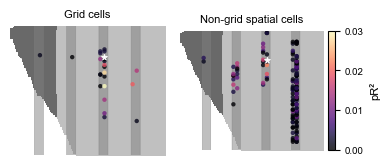

In [15]:
import matplotlib as mpl

fig, axs = plt.subplots(1,2, figsize=(4, 2.5), sharey=True)  # 2 rows, 1 column

for i, (df, title) in enumerate([(gcs, "Grid cells"), (ngs, "Non-grid spatial cells")]):
    plot_df = df.copy()
    plot_df = plot_df[plot_df['cluster_id'] != test_grid_cell_id]
    pr2_dict = dict(pr2_results)
    plot_df['pR2'] = plot_df['cluster_id'].map(pr2_dict)
    norm = mpl.colors.Normalize(vmin=0, vmax=0.03)
    cmap = plt.cm.magma

    ax = axs[i]
    unique_colors = np.unique(annotation_colors)
    for color in unique_colors:
        border_points = extract_border(annotation_colors, color, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax.scatter(x_points, y_points, color=color, s=1, label=color, rasterized=True)
    plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                   probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')

    sc = ax.scatter(
        plot_df['probe_x'], plot_df['probe_y'],
        c=plot_df['pR2'], cmap=cmap, norm=norm, marker='o', s=10, alpha=0.8, edgecolor='none'
    )

    test_cell = all_by_anatomy[all_by_anatomy['cluster_id'] == test_grid_cell_id]
    if not test_cell.empty:
        ax.scatter(
            test_cell['probe_x'], test_cell['probe_y'],
            marker='*', s=20, color='white', edgecolor='white', linewidth=0.6, zorder=10, label='Test grid cell'
        )

    ax.set_ylim(400, 1400)
    ax.set_title(title, fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

# Adjust colorbar position to the right and make it smaller, set ticks
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(sc, cax=cax, ticks=[0, 0.01, 0.02, 0.03])
cbar.ax.tick_params(labelsize=7)
cbar.set_label('pR²', fontsize=8)

plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_probe_brainrender_pR2_subplot.pdf', bbox_inches='tight', dpi=500)
plt.show()

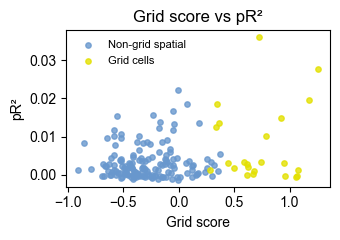

In [16]:
# Scatter plot of grid score vs pR2 for both non-grid spatial cells (ngs) and grid cells (gcs)
import matplotlib.pyplot as plt

pr2_dict = dict(pr2_results)

# Prepare data for both cell types
ngs_plot = ngs.copy()
ngs_plot['pR2'] = ngs_plot['cluster_id'].map(pr2_dict)
gcs_plot = gcs[gcs['cluster_id'] != test_grid_cell_id].copy()  # Exclude the test grid cell
gcs_plot['pR2'] = gcs_plot['cluster_id'].map(pr2_dict)

plt.figure(figsize=(3.5, 2.5))
plt.scatter(ngs_plot['grid_score'], ngs_plot['pR2'], color='#6897CD', s=15, alpha=0.8, label='Non-grid spatial')
plt.scatter(gcs_plot['grid_score'], gcs_plot['pR2'], color='#E3E000', s=15, alpha=0.8, label='Grid cells')
plt.xlabel('Grid score')
plt.ylabel('pR²')
plt.title('Grid score vs pR²')
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

make a plot showing both the open field and vr rate maps ranked by the pR2 to the target cell,
make this with the target cell next to it. 

Plotting cell 1/10 with cluster_id 160 and pR² 0.0360
29 23
Plotting cell 2/10 with cluster_id 184 and pR² 0.0277
29 23
Plotting cell 3/10 with cluster_id 389 and pR² 0.0197
29 23
Plotting cell 4/10 with cluster_id 194 and pR² 0.0184
29 23
Plotting cell 5/10 with cluster_id 411 and pR² 0.0148
29 23
Plotting cell 6/10 with cluster_id 144 and pR² 0.0135
29 23
Plotting cell 7/10 with cluster_id 210 and pR² 0.0126
29 23
Plotting cell 8/10 with cluster_id 133 and pR² 0.0101
29 23
Plotting cell 9/10 with cluster_id 217 and pR² 0.0033
29 23
Plotting cell 10/10 with cluster_id 213 and pR² 0.0033
29 23


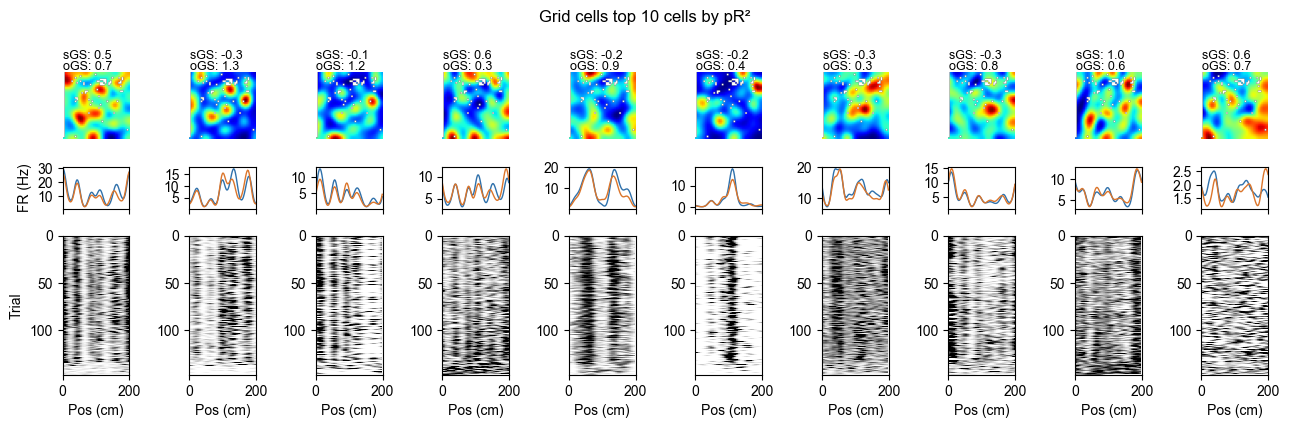

Plotting cell 1/10 with cluster_id 198 and pR² 0.0223
29 23
Plotting cell 2/10 with cluster_id 186 and pR² 0.0187
29 23
Plotting cell 3/10 with cluster_id 211 and pR² 0.0166
29 23
Plotting cell 4/10 with cluster_id 61 and pR² 0.0157
29 23
Plotting cell 5/10 with cluster_id 108 and pR² 0.0153
29 23
Plotting cell 6/10 with cluster_id 86 and pR² 0.0137
29 23
Plotting cell 7/10 with cluster_id 163 and pR² 0.0135
29 23
Plotting cell 8/10 with cluster_id 101 and pR² 0.0133
29 23
Plotting cell 9/10 with cluster_id 89 and pR² 0.0124
29 23
Plotting cell 10/10 with cluster_id 226 and pR² 0.0118
29 23


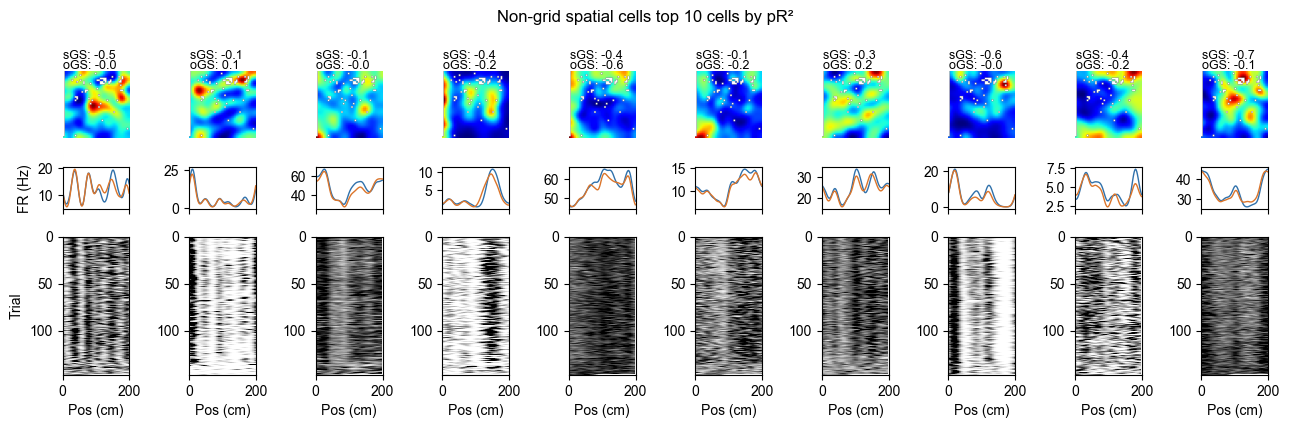

: 

In [ ]:
import matplotlib.pyplot as plt

def plot_n_rate_maps(df, pr2_dict, n=10, title_prefix="", ascending=False):
    """
    Plot open field and VR rate maps for the top n cells ranked by pR².
    
    Args:
        df: DataFrame with at least 'cluster_id' column.
        pr2_dict: dict mapping cluster_id to pR².
        n: number of top cells to plot.
        plot_open_field_rate_map: function(ax, cluster_id, ...) to plot open field map.
        plot_vr_rate_map: function(ax, cluster_id, ...) to plot VR map.
        title_prefix: string for figure title.
    """
    # Add pR2 to df and sort
    df = df.copy()
    df['pR2'] = df['cluster_id'].map(pr2_dict)
    df = df.sort_values('pR2', ascending=ascending).head(n)
    
    figsize=(rm_figsize[0]*n*1.3, (rm_figsize[1]*1.45) + 2)
    fig, axs = plt.subplots(3, n, figsize=figsize, height_ratios=[0.5,0.3,1])
    if n == 1:
        axs = axs.reshape(1, 2)
    for i, row in enumerate(df.itertuples()):
        print(f"Plotting cell {i+1}/{n} with cluster_id {row.cluster_id} and pR² {row.pR2:.4f}")
        cid = row.cluster_id
        # OF
        ax_of = axs[0, i]
        plot_open_field_rate_map_optimal_ax(ax_of, cid, mouse, day, df, source_path=None)
        # VR
        ax_vr = axs[1, i]
        plot_vr_rate_map_avg_ax(ax_vr, cid, mouse, day, df, source_path=None)
        ax_vr.set_xlim(0,tl)
        ax_vr.set_xticks([0, tl])
        ax_vr.set_xticklabels(['', ''])
        ax_vr2 = axs[2, i]
        plot_vr_rate_map_trials_ax(ax_vr2, cid, mouse, day, df, source_path=None)
        ax_vr2.set_xticks([0, tl])
        # set y ticks in increments of 50
        max_trial = 140
        ax_vr2.set_yticks(np.arange(0, max_trial+1, 50))
        if i == 0:
            ax_vr.set_ylabel('FR (Hz)', fontsize=10)
            ax_vr2.set_ylabel('Trial', fontsize=10)

    if ascending:
        plt.suptitle(f"{title_prefix} bottom {n} cells by pR²", fontsize=12)
    else:
        plt.suptitle(f"{title_prefix} top {n} cells by pR²", fontsize=12)

    plt.tight_layout()
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_{title_prefix.replace(" ","_")}_{"bottom" if ascending else "top"}_{n}_by_pR2_rate_maps.pdf', bbox_inches='tight', dpi=500)
    plt.show()

# remove test_grid_cell_id from gcs
gcs_tmp = gcs[gcs['cluster_id'] != test_grid_cell_id]
plot_n_rate_maps(gcs_tmp, pr2_dict, n=10, title_prefix="Grid cells", ascending=False)
plot_n_rate_maps(ngs, pr2_dict, n=10, title_prefix="Non-grid spatial cells", ascending=False)

appendix 1 hyperparameter search

In [17]:
from hyperopt import fmin, hp, Trials, tpe, STATUS_OK

# Makes sure these are in model.params, otherwise you'll get a key error
space4rf = {
    'silent': 1,
    'learning_rate': hp.choice('learning_rate', [0.01, 0.05, 0.1, 0.2, 0.3]),
    'min_child_weight': hp.choice('min_child_weight', [1, 2, 5, 10]),
    'n_estimators': hp.choice('n_estimators', [100, 300, 500, 700, 1000]),
    'subsample': hp.choice('subsample', [0.5, 0.6, 0.7, 0.8, 1.0]),
    'max_depth': hp.choice('max_depth', [3, 5, 7, 9]),
    'gamma': hp.choice('gamma', [0, 0.1, 0.3, 0.5, 1.0]),
}

#object that holds iteration results
trials = Trials()

#define model
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = False, spike_history=True, # We can choose!
                         window = time_bs, #this dataset has 50ms time bins
                         n_filters = 5,
                         max_time = int(time_bs*10))

#function to minimize
def fnc(params):
    print(params)

    # make sure parameters are integers that need to be. 
    params['silent'] = int(params['silent'])
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    xgb_history.set_params(params)
    
    # Remember that X and y have been defined above.
    Y_hat, PR2s = xgb_history.fit_cv(X,y, n_cv = 5, verbose = 0, continuous_folds = True)

    # return negative since hyperopt always minimizes the function
    return -np.mean(PR2s)

hyperoptBest = fmin(fnc, space4rf, algo=tpe.suggest, max_evals=500, 
                    trials=trials, return_argmin=False)


{'gamma': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 700, 'silent': 1, 'subsample': 0.6}
{'gamma': 0.3, 'learning_rate': 0.3, 'max_depth': 7, 'min_child_weight': 10, 'n_estimators': 300, 'silent': 1, 'subsample': 0.7}
{'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 100, 'silent': 1, 'subsample': 1.0}
{'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 1000, 'silent': 1, 'subsample': 0.6}
{'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 700, 'silent': 1, 'subsample': 0.6}
{'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 100, 'silent': 1, 'subsample': 0.6}
{'gamma': 0, 'learning_rate': 0.3, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 700, 'silent': 1, 'subsample': 0.7}
{'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 300, 'sil

In [18]:
hyperoptBest


{
    'gamma': 0,
    'learning_rate': 0.05,
    'max_depth': 5,
    'min_child_weight': 2,
    'n_estimators': 300,
    'silent': 1,
    'subsample': 0.5
}